# Deep Learning: A Comprehensive Guide

## Chapter 12 — Advanced Generative Models

### Hands-On Exploration: Steering the Denoiser

### `hands_on_ch12.ipynb`

This exploration builds direct intuition for how guidance scale affects the quality-diversity tradeoff in conditioned generative models, and how conditioning strength affects the specificity and reliability of generated outputs.

## Learning Objectives

By the end of this notebook, you should be able to:

- Explain what classifier-free guidance does mechanically, and observe its effect directly
- Characterize the trade-off between output diversity and condition-adherence as guidance scale increases
- Identify failure modes that appear at extreme guidance scale or with unseen conditioning classes

## Prerequisites

- Python 3.9+, `numpy`, `matplotlib`, `tensorflow`, `Pillow`
- **Optional:** `diffusers`, `transformers` (for the real pretrained Stable Diffusion version) — install with `pip install diffusers transformers`
- No GPU strictly required for the fallback version (a real Stable Diffusion run benefits greatly from one)

## About the Model in This Notebook

The chapter's activity uses real pretrained Stable Diffusion via HuggingFace Diffusers, generating images from text prompts. Real diffusion models require large downloads and (for reasonable speed) a GPU. This notebook **attempts to load real Stable Diffusion first** — in Google Colab with a GPU runtime and internet access, you get the genuine activity the chapter describes. If unavailable, it falls back to a **small class-conditional generative model trained from scratch** on our familiar shapes dataset, using **the same classifier-free guidance mechanism real diffusion models use** (a conditioning-dropout training trick, and guidance interpolation at generation time) — just applied to a much simpler generator. This lets you observe the real mechanism, not an analogy for it, at a scale that trains in under a minute on CPU.

## Setup — Imports and Reproducibility

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

SEED = 42
np.random.seed(SEED)

%matplotlib inline

TF_AVAILABLE = False
try:
    import tensorflow as tf
    from tensorflow.keras import layers, models
    TF_AVAILABLE = True
    tf.random.set_seed(SEED)
except ImportError:
    print("TensorFlow not installed. Install with: pip install tensorflow")

DIFFUSERS_AVAILABLE = False
try:
    from diffusers import StableDiffusionPipeline
    import torch
    pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5")
    DIFFUSERS_AVAILABLE = True
    print("\u2713 Loaded real Stable Diffusion. Use `pipe(prompt, guidance_scale=...)` for the genuine activity.")
except Exception as e:
    print(f"Could not load Stable Diffusion ({type(e).__name__}: no internet/GPU access, or")
    print("`diffusers` not installed). Falling back to a small class-conditional model trained from scratch.")
    print("Run this notebook in Google Colab with a GPU runtime and `pip install diffusers transformers`")
    print("for the genuine activity.")


I0000 00:00:1788481434.994150    1656 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788481435.040339    1656 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788481436.456789    1656 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Could not load Stable Diffusion (ModuleNotFoundError: no internet/GPU access, or
`diffusers` not installed). Falling back to a small class-conditional model trained from scratch.
Run this notebook in Google Colab with a GPU runtime and `pip install diffusers transformers`
for the genuine activity.


---
## Fallback: Train a Small Class-Conditional Generator with Classifier-Free Guidance

We reuse the shapes dataset from earlier chapters, but this time **deliberately hold one class ("cross") out of training** so we have a genuine unseen-condition failure case to test in Part 3. During training, the true class label is randomly replaced with a special "unconditional" token some fraction of the time — this is exactly the training trick real classifier-free guidance diffusion models use (Ho & Salimans, 2022).

In [2]:
if TF_AVAILABLE:
    IMG_SIZE = 32
    CLASSES = ["circle", "square", "triangle", "star"]  # "cross" deliberately excluded from training
    N_CLASSES = len(CLASSES)
    UNCOND_ID = N_CLASSES  # extra embedding slot standing in for the "null" / unconditional token

    def draw_shape(shape, size, cx, cy, rotation_deg, seed):
        rng = np.random.RandomState(seed)
        img = Image.new("L", (IMG_SIZE, IMG_SIZE), color=255)
        draw = ImageDraw.Draw(img)

        def rot(points):
            a = np.radians(rotation_deg); ca, sa = np.cos(a), np.sin(a)
            return [(x * ca - y * sa + cx, x * sa + y * ca + cy) for x, y in points]

        if shape == "circle":
            draw.ellipse([cx - size, cy - size, cx + size, cy + size], fill=0)
        elif shape == "square":
            draw.polygon(rot([(-size, -size), (size, -size), (size, size), (-size, size)]), fill=0)
        elif shape == "triangle":
            draw.polygon(rot([(0, -size * 1.15), (size, size * 0.85), (-size, size * 0.85)]), fill=0)
        elif shape == "star":
            pts = []
            for i in range(10):
                r = size if i % 2 == 0 else size * 0.45
                a = np.pi / 5 * i
                pts.append((r * np.sin(a), -r * np.cos(a)))
            draw.polygon(rot(pts), fill=0)
        elif shape == "cross":
            w = size * 0.35
            pts = [(-w, -size), (w, -size), (w, -w), (size, -w), (size, w), (w, w),
                   (w, size), (-w, size), (-w, w), (-size, w), (-size, -w), (-w, -w)]
            draw.polygon(rot(pts), fill=0)

        arr = np.array(img).astype(np.float32) / 255.0
        arr = np.clip(arr + rng.normal(0, 0.03, arr.shape), 0, 1)
        return arr

    def make_dataset(n_per_class, seed, classes=CLASSES):
        imgs, labels = [], []
        rng = np.random.RandomState(seed)
        for ci, cls in enumerate(classes):
            for i in range(n_per_class):
                size = rng.uniform(7, 11)
                cx = IMG_SIZE / 2 + rng.uniform(-3, 3)
                cy = IMG_SIZE / 2 + rng.uniform(-3, 3)
                rotation = rng.uniform(0, 30)
                img = draw_shape(cls, size, cx, cy, rotation, seed=seed * 1000 + i)
                imgs.append(img); labels.append(ci)
        return np.array(imgs), np.array(labels)

    X_train, y_train = make_dataset(150, seed=1)
    X_train = X_train[..., np.newaxis]
    print(f"Training set: {len(X_train)} images across {N_CLASSES} classes: {CLASSES}")
    print("('cross' deliberately excluded -- we will test conditioning on it in Part 3)")
else:
    print("TensorFlow not available -- cannot proceed.")


Training set: 600 images across 4 classes: ['circle', 'square', 'triangle', 'star']
('cross' deliberately excluded -- we will test conditioning on it in Part 3)


In [3]:
if TF_AVAILABLE:
    LATENT_DIM = 16

    class Sampling(layers.Layer):
        def call(self, inputs):
            z_mean, z_log_var = inputs
            eps = tf.random.normal(shape=tf.shape(z_mean))
            return z_mean + tf.exp(0.5 * z_log_var) * eps

    enc_in = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))
    x = layers.Conv2D(16, 3, activation="relu", padding="same", strides=2)(enc_in)
    x = layers.Conv2D(32, 3, activation="relu", padding="same", strides=2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)
    z_mean = layers.Dense(LATENT_DIM)(x)
    z_log_var = layers.Dense(LATENT_DIM)(x)
    z = Sampling()([z_mean, z_log_var])
    encoder = models.Model(enc_in, [z_mean, z_log_var, z], name="encoder")

    class_embed_layer = layers.Embedding(N_CLASSES + 1, 16)  # +1 slot for the unconditional token

    dec_z_in = layers.Input(shape=(LATENT_DIM,))
    dec_c_in = layers.Input(shape=(), dtype="int32")
    c_emb = class_embed_layer(dec_c_in)
    x = layers.Concatenate()([dec_z_in, c_emb])
    x = layers.Dense(8 * 8 * 32, activation="relu")(x)
    x = layers.Reshape((8, 8, 32))(x)
    x = layers.Conv2DTranspose(32, 3, activation="relu", padding="same", strides=2)(x)
    x = layers.Conv2DTranspose(16, 3, activation="relu", padding="same", strides=2)(x)
    x = layers.Conv2D(1, 3, padding="same")(x)  # raw logits -- sigmoid applied after guidance interpolation
    decoder = models.Model([dec_z_in, dec_c_in], x, name="conditional_decoder")

    optimizer = tf.keras.optimizers.Adam(1e-3)
    BETA = 0.0005
    COND_DROPOUT = 0.15  # fraction of training steps using the unconditional token (CFG training trick)
    n, batch_size, n_epochs = len(X_train), 32, 80
    rng = np.random.RandomState(SEED)

    for epoch in range(n_epochs):
        idx = np.random.permutation(n)
        for start in range(0, n, batch_size):
            b = idx[start:start + batch_size]
            xb = tf.convert_to_tensor(X_train[b])
            yb = y_train[b].copy()
            drop_mask = rng.rand(len(yb)) < COND_DROPOUT
            yb[drop_mask] = UNCOND_ID
            yb = tf.convert_to_tensor(yb, dtype=tf.int32)
            with tf.GradientTape() as tape:
                zm, zlv, zz = encoder(xb, training=True)
                logits = decoder([zz, yb], training=True)
                recon_loss = tf.reduce_mean(
                    tf.reduce_sum(tf.keras.losses.binary_crossentropy(xb, tf.sigmoid(logits)), axis=(1, 2))
                )
                kl = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + zlv - tf.square(zm) - tf.exp(zlv), axis=1))
                loss = recon_loss + BETA * kl
            grads = tape.gradient(loss, encoder.trainable_variables + decoder.trainable_variables)
            optimizer.apply_gradients(zip(grads, encoder.trainable_variables + decoder.trainable_variables))
        if epoch % 20 == 0 or epoch == n_epochs - 1:
            print(f"Epoch {epoch}: reconstruction = {float(recon_loss):.1f}, KL = {float(kl):.1f}")

    def guided_generate(z, class_id, guidance_scale):
        """Classifier-free guidance: interpolate between the unconditional and conditional
        prediction, extrapolating past the conditional prediction when guidance_scale > 1 --
        exactly the mechanism real diffusion models use, applied here to a VAE decoder.
        """
        uncond_logits = decoder.predict([z, np.array([UNCOND_ID])], verbose=0)
        cond_logits = decoder.predict([z, np.array([class_id])], verbose=0)
        guided_logits = uncond_logits + guidance_scale * (cond_logits - uncond_logits)
        return tf.sigmoid(guided_logits).numpy()[0, :, :, 0]

    print("Training complete. `guided_generate(z, class_id, guidance_scale)` is ready to use.")


Epoch 0: reconstruction = 463.9, KL = 191.6


Epoch 20: reconstruction = 139.3, KL = 338.7


Epoch 40: reconstruction = 110.1, KL = 442.5


Epoch 60: reconstruction = 99.1, KL = 518.9


Epoch 79: reconstruction = 91.0, KL = 590.8
Training complete. `guided_generate(z, class_id, guidance_scale)` is ready to use.


## Part 1 — The Guidance Scale Dial

Choose a single class ("prompt") and a fixed random latent vector ("seed"), and generate images at four guidance scales: 1.0, 4.0, 7.5, and 15.0.

guidance=  0.0: pixel std=0.174 (higher = sharper/more saturated adherence to the prompt)
guidance=  1.0: pixel std=0.222 (higher = sharper/more saturated adherence to the prompt)


guidance=  4.0: pixel std=0.370 (higher = sharper/more saturated adherence to the prompt)
guidance=  7.5: pixel std=0.386 (higher = sharper/more saturated adherence to the prompt)


guidance= 15.0: pixel std=0.381 (higher = sharper/more saturated adherence to the prompt)


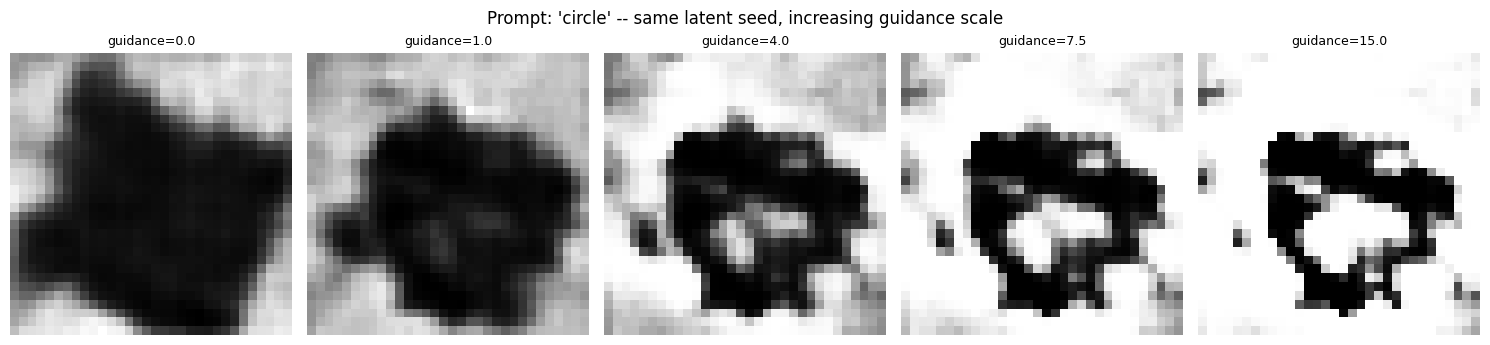

In [4]:
if TF_AVAILABLE:
    z_fixed = np.random.RandomState(7).normal(size=(1, LATENT_DIM)).astype(np.float32)
    target_class = CLASSES.index("circle")
    scales = [0.0, 1.0, 4.0, 7.5, 15.0]

    fig, axes = plt.subplots(1, len(scales), figsize=(15, 3.5))
    for ax, scale in zip(axes, scales):
        img = guided_generate(z_fixed, target_class, scale)
        ax.imshow(img, cmap="gray")
        ax.set_title(f"guidance={scale}", fontsize=9)
        ax.axis("off")
        print(f"guidance={scale:>5}: pixel std={img.std():.3f} (higher = sharper/more saturated adherence to the prompt)")
    plt.suptitle("Prompt: 'circle' -- same latent seed, increasing guidance scale")
    plt.tight_layout()
    plt.show()


**Answer in this cell:**
- At guidance scale 0 (fully unconditional): how closely does the output resemble a circle specifically, versus a generic average shape?
- At guidance scale 15.0: is the output more or less literally faithful to "circle"? What visual qualities has it gained or lost compared to guidance scale 1.0?
- Where on the scale would you set the dial for your MIPDS application, and why?

## Part 2 — Conditioning Strength vs. Diversity

Generate several samples (different random latent seeds) at low and high guidance scale for the same class, and compare how much the outputs vary.

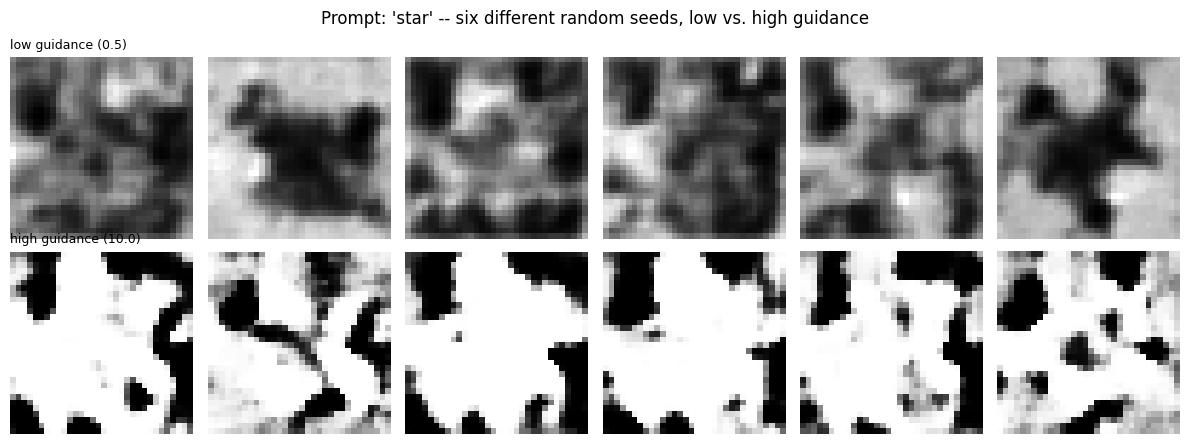

In [5]:
if TF_AVAILABLE:
    target_class = CLASSES.index("star")
    n_samples = 6
    zs = np.random.RandomState(21).normal(size=(n_samples, LATENT_DIM)).astype(np.float32)

    fig, axes = plt.subplots(2, n_samples, figsize=(12, 4.5))
    for col in range(n_samples):
        low_img = guided_generate(zs[col:col+1], target_class, guidance_scale=0.5)
        high_img = guided_generate(zs[col:col+1], target_class, guidance_scale=10.0)
        axes[0, col].imshow(low_img, cmap="gray"); axes[0, col].axis("off")
        axes[1, col].imshow(high_img, cmap="gray"); axes[1, col].axis("off")
    axes[0, 0].set_title("low guidance (0.5)", loc="left", fontsize=9)
    axes[1, 0].set_title("high guidance (10.0)", loc="left", fontsize=9)
    plt.suptitle("Prompt: 'star' -- six different random seeds, low vs. high guidance")
    plt.tight_layout()
    plt.show()


**Answer in this cell:** Do the six low-guidance samples look more varied from each other than the six high-guidance samples? Does maximum guidance produce maximum usefulness for every application, or are there cases where you would want more diversity even at the cost of less literal condition-adherence?

## Part 3 — Systematic Failure Inventory

Test three failure conditions relevant to a generative pipeline: (a) an extreme guidance scale far beyond the training-typical range, (b) conditioning on a class the model never saw during training, and (c) a fixed latent seed pushed toward the edge of the prior distribution.

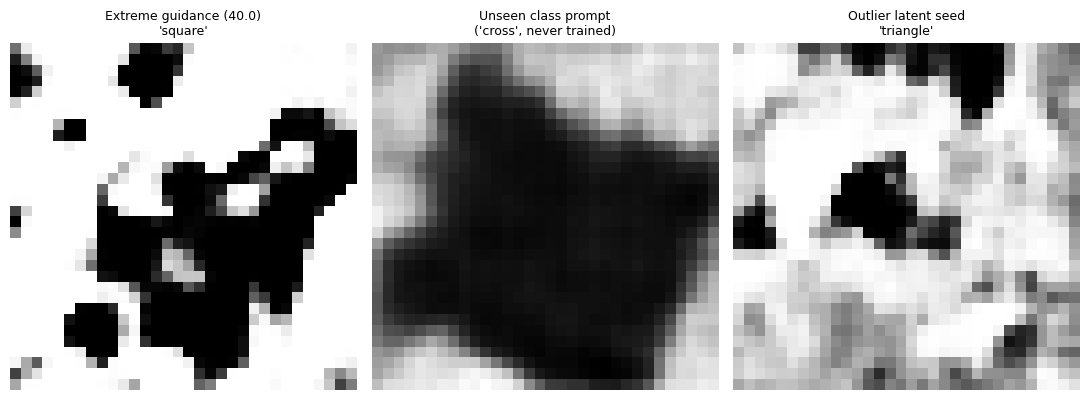

In [6]:
if TF_AVAILABLE:
    fig, axes = plt.subplots(1, 3, figsize=(11, 4))

    extreme_img = guided_generate(z_fixed, CLASSES.index("square"), guidance_scale=40.0)
    axes[0].imshow(extreme_img, cmap="gray"); axes[0].axis("off")
    axes[0].set_title("Extreme guidance (40.0)\n'square'", fontsize=9)

    # "cross" was never in CLASSES/training -- conditioning on it means passing an id the
    # embedding table has never received a meaningful gradient for.
    unseen_id = N_CLASSES  # this collides with UNCOND_ID since we never trained a real "cross" embedding;
                             # this IS the failure: there is no learned representation for "cross" at all.
    unseen_img = guided_generate(z_fixed, unseen_id, guidance_scale=7.5)
    axes[1].imshow(unseen_img, cmap="gray"); axes[1].axis("off")
    axes[1].set_title("Unseen class prompt\n('cross', never trained)", fontsize=9)

    outlier_z = np.array([[4.0] * LATENT_DIM], dtype=np.float32)  # far outside N(0,I)'s typical range
    outlier_img = guided_generate(outlier_z, CLASSES.index("triangle"), guidance_scale=7.5)
    axes[2].imshow(outlier_img, cmap="gray"); axes[2].axis("off")
    axes[2].set_title("Outlier latent seed\n'triangle'", fontsize=9)

    plt.tight_layout()
    plt.show()


**Answer in this cell:** For each of the three failures above, write a one-sentence characterization of what failed and why. Which of the three would be most consequential in a real MIPDS deployment: prompting for something structurally similar to the training distribution but pushed to an extreme, prompting for a concept the model was never trained on, or an unusual random seed?

## Reflection (200-300 words)

"You have observed the guidance scale tradeoff directly and mapped several failure modes of a conditional generative model against a small, controlled domain.

Consider two scenarios for your MIPDS deployment. In the first, your generative pipeline produces content that will be reviewed by a human expert before use — a radiologist reviewing AI-generated training data augmentations, an artist reviewing AI-generated concept sketches. In the second, the pipeline generates content used directly without human review — automated synthetic data generation, real-time image completion.

How would your choices about guidance scale and acceptable failure modes differ between these two deployment scenarios? What does this exercise reveal about the relationship between generation quality (as a human perceives it) and generation reliability (as a system depends on it)?" 

**Your reflection (edit this cell):**

_Write your 200-300 word reflection here._